In [6]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain.tools import tool
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import HumanMessage
load_dotenv()


@tool
def get_weather(city:str):
    """Returns the weather for the given city"""
    return f"The weather of the {city} is 25 degree centigrate"

tools = [get_weather]
llm_with_tools = ChatOpenAI(model='gpt-4o-mini').bind_tools(tools)

class State(TypedDict):
    messages : Annotated[list, add_messages]
    

def chatbot(state:State):
    messages = state['messages']
    result = llm_with_tools.invoke(messages)
    return {'messages':[result]}

graph = StateGraph(State)

graph.add_node('chatbot', chatbot)
graph.add_node('tool_node', ToolNode(tools))

graph.add_edge(START, 'chatbot')
graph.add_conditional_edges(
    'chatbot',
    tools_condition,
    {'tools':'tool_node', '__end__': END}
)
graph.add_edge('tool_node', 'chatbot')

app = graph.compile()

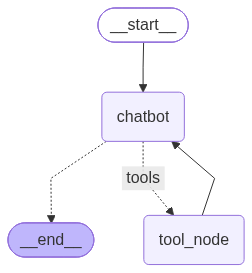

In [7]:
from IPython.display import display, Image

display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
for event in app.stream({
    'messages':[
        HumanMessage(content='Whats the weather in chennai?')
    ]}, stream_mode='values'
):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Whats the weather in chennai?
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_nWjExNBpwuLEJYhubqWMYYMn)
 Call ID: call_nWjExNBpwuLEJYhubqWMYYMn
  Args:
    city: Chennai
================================= Tool Message =================================
Name: get_weather

The weather of the Chennai is 25 degree centigrate
================================== Ai Message ==================================

The weather in Chennai is currently 25 degrees Celsius.
